In [9]:
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt


In [10]:
df = pd.read_csv('day.csv')
df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [11]:
X = df.drop('cnt', axis=1)
y = df['cnt']

X['dteday'] = pd.to_datetime(X['dteday'])
X['year'] = X['dteday'].dt.year
X['month'] = X['dteday'].dt.month
X['day'] = X['dteday'].dt.day
X = X.drop('dteday', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_features = ['season', 'weathersit', 'mnth', 'holiday', 'weekday', 'workingday']
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Normalizar las características (KNN es sensible a escalas)
numerical_features = ['temp', 'atemp', 'hum', 'windspeed','year', 'month', 'day']
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [12]:
nn = []
r2 = []
for i in range(2, 50):
    nn.append(i)
    neigh = KNeighborsRegressor(n_neighbors=i)
    neigh.fit(X_train, y_train)
    predicciones = neigh.predict(X_test)
    r2.append(r2_score(y_pred=predicciones, y_true=y_test))

El mejor valor de k es: 5
El mejor valor de R^2 es: 0.9104070726614973


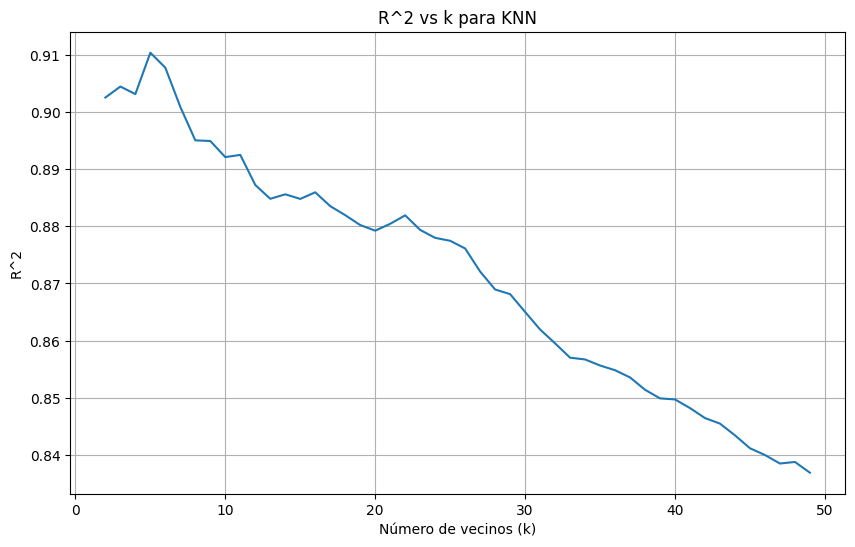

In [13]:
best_k = nn[np.argmax(r2)]
print(f"El mejor valor de k es: {best_k}")
print(f"El mejor valor de R^2 es: {np.max(r2)}")

# Graficar el R^2 vs k
plt.figure(figsize=(10, 6))
plt.plot(nn, r2)
plt.xlabel("Número de vecinos (k)")
plt.ylabel("R^2")
plt.title("R^2 vs k para KNN")
plt.grid(True)
plt.show()

En la gráfica podemos ver que el mejor valor para utilizar es de 5, esto nos da un muy buen R^2 (0.91). Es decir que utilizando la infromación de únicamente 5 puntos vecinos nos arroja el mejor modelo para predecir la variable "y" (cnt).